# 4. Detailed Performance & Financial Analysis

**Objective**: Rigorous evaluation using comprehensive metrics beyond simple accuracy. Corresponds to **Section 5 (Performance Analysis)** of the Report.

**Outputs**:
- `roc_curve_analysis.png`
- `pr_curve_analysis.png` (New!)
- `confusion_matrix_final.png`
- `calibration_curve.png`
- `roi_analysis.png`

In [10]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, 
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
)
from app.src import config

sns.set_theme(style="whitegrid", context="talk")
SAVE_DIR = config.RESULTS_DIR

# Load Model and Test Data
test_df = pd.read_csv(config.TEST_DATA_PATH)
y_test = test_df[config.TARGET_COL]
X_test = test_df.drop(config.TARGET_COL, axis=1)
model = joblib.load(config.MODEL_PATH)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

## 4.1 Advanced Metrics Table
Calculating Specificity, F1, and Brier Score.

In [3]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
brier = brier_score_loss(y_test, y_prob)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall (Sensitivity)': recall_score(y_test, y_pred),
    'Specificity': specificity,
    'F1 Score': f1_score(y_test, y_pred),
    'Brier Score (Prob. Error)': brier
}

results_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Value'])
print(results_df)
# Optionally save this table as image or latex if needed

                      Metric     Value
0                   Accuracy  0.817293
1                  Precision  0.834082
2       Recall (Sensitivity)  0.881440
3                Specificity  0.711887
4                   F1 Score  0.857107
5  Brier Score (Prob. Error)  0.125585


## 4.2 Precision-Recall Curve
Crucial for imbalanced datasets. Shows the trade-off between Precision and Recall for different thresholds.

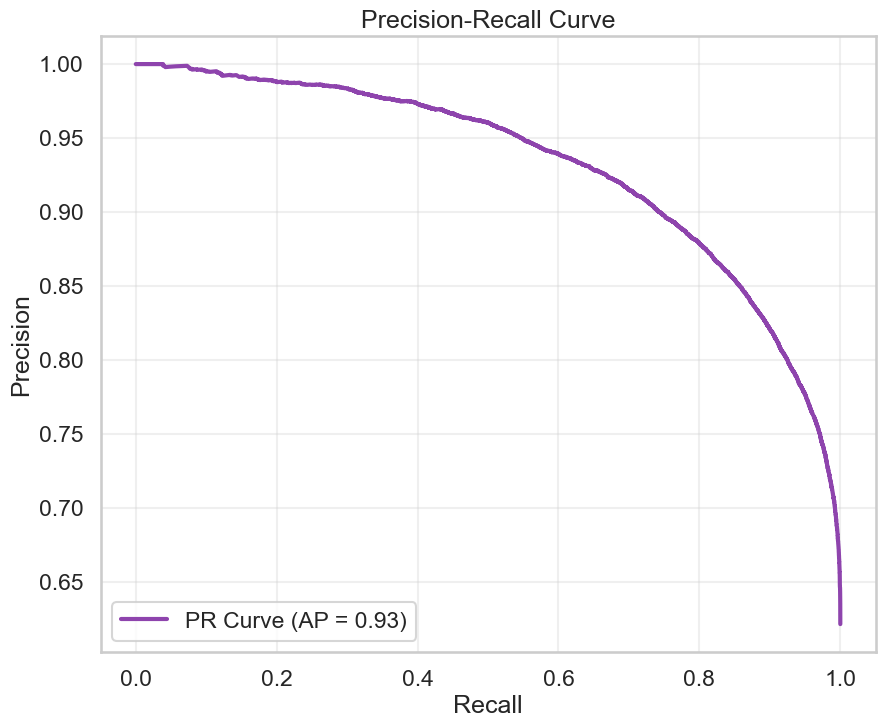

In [4]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='#8e44ad', lw=3, label=f'PR Curve (AP = {avg_prec:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(SAVE_DIR, 'pr_curve_analysis.png'), dpi=300)
plt.show()

## 4.3 ROC Curve

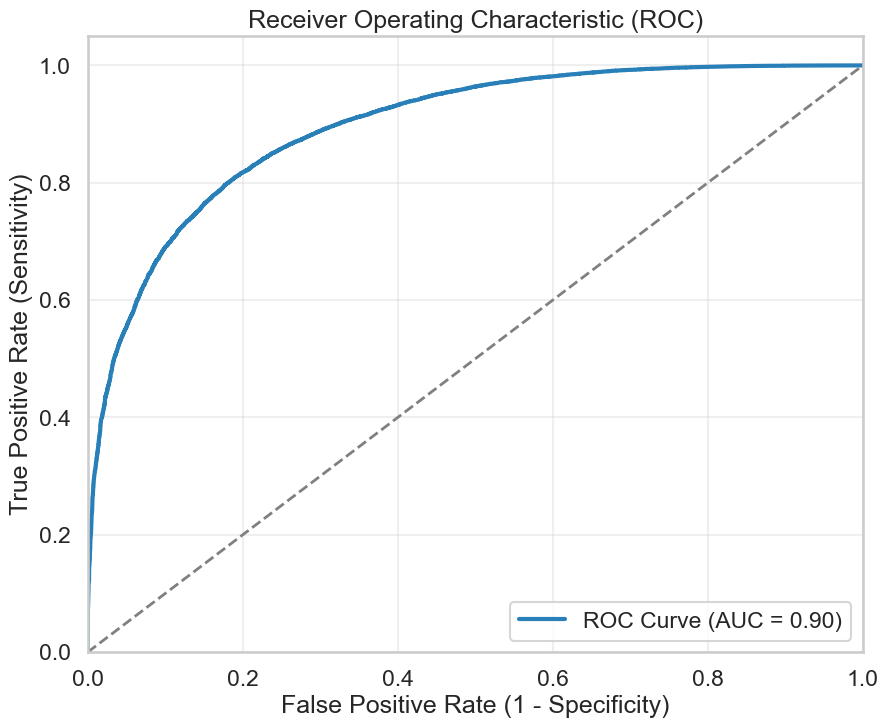

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#2980b9', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve_analysis.png'), dpi=300)
plt.show()

## 4.4 Confusion Matrix

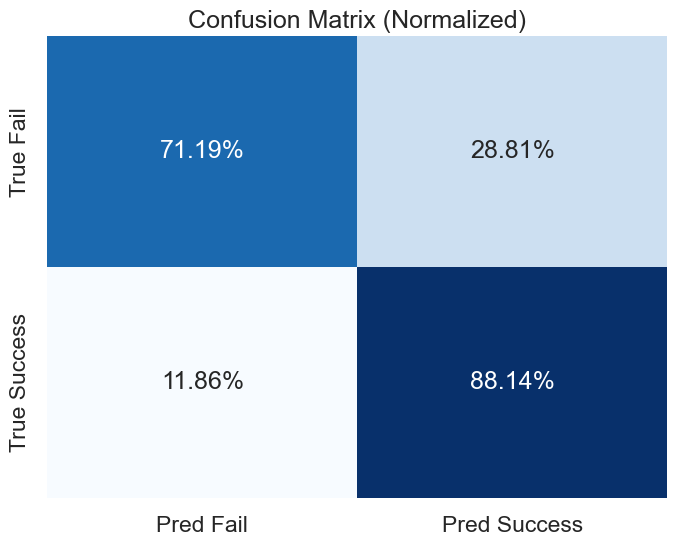

In [6]:
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', cbar=False,
            xticklabels=['Pred Fail', 'Pred Success'],
            yticklabels=['True Fail', 'True Success'])
plt.title('Confusion Matrix (Normalized)')
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix_final.png'), dpi=300)
plt.show()

## 4.5 Calibration Curve

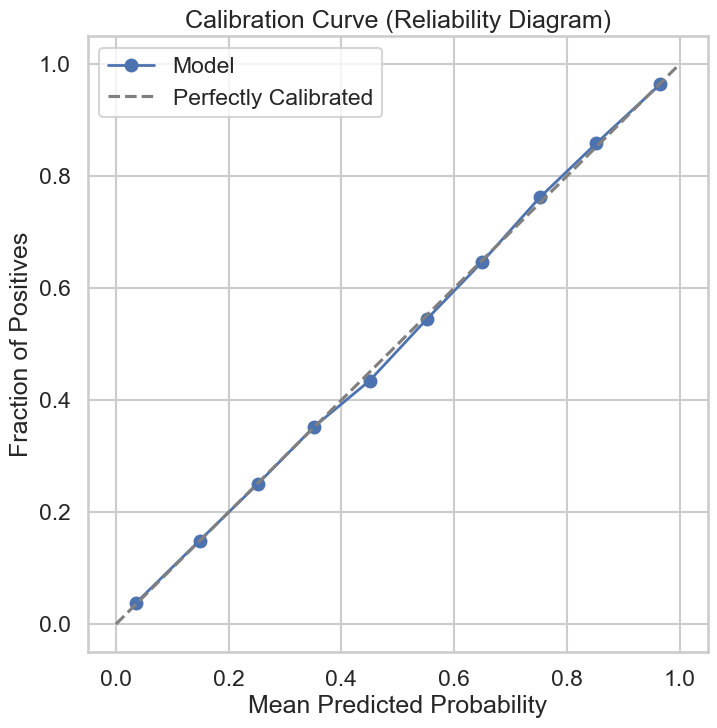

In [11]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, 'calibration_curve.png'), dpi=300)
plt.show()

## 4.6 Financial ROI Analysis

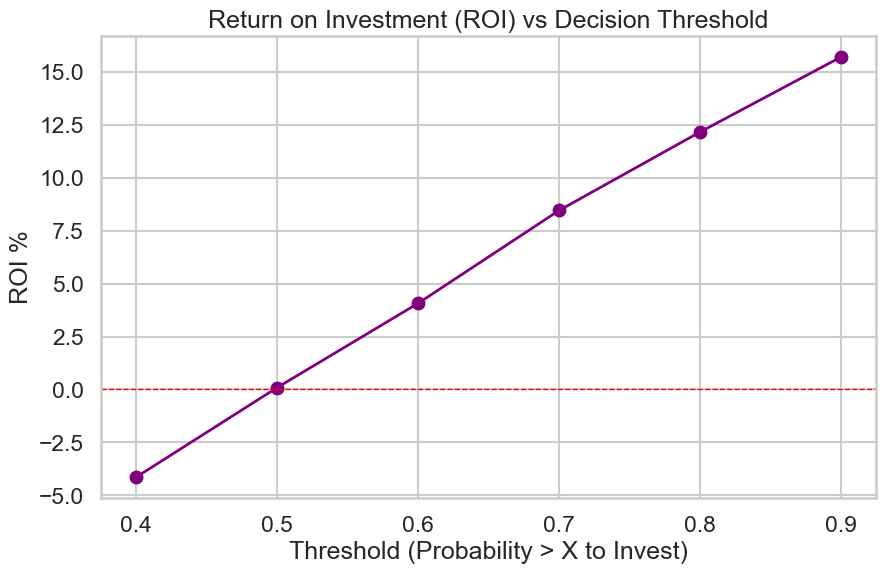

In [12]:
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
roi_scores = []

for t in thresholds:
    preds = (y_prob >= t)
    invested = preds.sum()
    if invested == 0: 
        roi_scores.append(0)
        continue
    successes = (preds & (y_test == 1)).sum()
    failures = invested - successes
    profit = (successes * 20) - (failures * 100)
    roi = (profit / (invested * 100)) * 100
    roi_scores.append(roi)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, roi_scores, marker='o', color='purple', lw=2)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Return on Investment (ROI) vs Decision Threshold')
plt.xlabel('Threshold (Probability > X to Invest)')
plt.ylabel('ROI %')
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, 'roi_analysis.png'), dpi=300)
plt.show()